In [ ]:
#Installing necessary packages in virutal environment
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scipy

# Introduction

The goal of this project is to analyze biodiversity data from the National Parks Service, particularly around various species observed in different national park locations.

This project will scope, analyze, prepare, plot data, and seek to explain the findings from the analysis.

Here are the questions that this project will attempt to answer:

- What is the distribution of the conservation status for species?
- Are certain types of species more likely to be endangered?
- Are the differences between species and their conservation status significant?
- Which animal is most prevalent and what is their distribution amongst parks?

**Data Sources:**

Both `Observations.csv` and `Species_info.csv` was provided by [Codecademy.com](https://www.codecademy.com).

Note: The data for this project is *inspired* by real data, but is mostly fictional.

## Scoping

Four sections below have been created to help guide this project's process and progress. The first section is the Project Goals, which will define the objectives and set the intentions of this project as a whole. Next, we will define the Data section, in which we will check to see if the given data sets are able to help us meet our defined project goals. Thirdly, we will have our Analysis section which will include the methods and questions aligned with our stated project goals. Lastly, we will have our Evaluation section where we will deliver our conclusions and findings upon the completion of our data analysis.

### Project Goals

In this project, we will imagine ourselves to be a biodiversity analyst hired by the National Park Service. The National Park Service has a goal to ensure the survival and prosperity of at-risk and endangered species residing in their parks, to not only protect these species, but to ensure that there is dense level of biodiversity within thier parks as well. With this in mind, our main objectives as a hired analyst will be to understand some key characteristics of each species along with their conservation status, as well as to understand each species and thier relationship to the national parks. Here are some questions which will help us to uncover these findings (same as previous):

- What is the distribution of conservation status for species?
- Are certain species more likely to be endangered?
- Are the differences between species and thier conservation status significant?
- Which animal is most prevalent and what is thier distribution amongst parks?

### Data

This project will conduct analysis using two data sets:

- `Species_info.csv` contains information regarding each species
- `Obervations.csv` contains information regarding the observation of species within each park location

### Analysis 

In this section, descriptive statistics and data visualization techniques will be employed to better understand out data. Statistical inference will also be used in order to test if observed values are statisticall significant. Key metrics that will be computed include:

1. Distributions
1. Counts
1. Relationships Between Species
1. Conservation Status of Species
1. Observation of Species in Parks

### Evaluation

In this section, we will revisit the stated goals and confirm that our analysis of the data is in alignment with the answers to the initial questions posed within our project (Goals section). This section will also refelct on our findings, as well as disclose if any of our initial questions were unable to be answered. This will also include limitations or is any of the analysis could have been done using different methodologies.

## Importing Python Modules

Import the necessary python modules that will be used in this project:

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Loading the Data

To analyze the status of conservation of species and their observations in national parks, we first load the datasets into pandas `DataFrames`. Once this has been done, we can then begin to analyze and visualize our data.

In the following lines of code, `Observations.csv` and `Species_info.csv` are read in as `DataFrames` called `observations` and `species` respectively. We then use the `.head()` method on each of our `DataFrames` to check the contents of the first five rows of data in each table.

#### species

The `species_info.csv` contains information on the different species found in the national parks. The columns include:
- **category** - The category taxonomy for each species
- **scientific_names** - The scientific name of each species
- **common_names** - The common names of each species
- **conservation_status** - The species conservation status

In [4]:
species = pd.read_csv('species_info.csv', encoding='utf-8')
species.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


#### observations

The `Observations.csv` contains information from recorded sightings of different species throughout the national parks in the last 7 days. The columns include:

- **scientific_name** - The scientific name of each species
- **park_name** - The name of the national park
- **observations** - The number of observations in the past 7 days

In [5]:
observations = pd.read_csv('observations.csv', encoding='utf-8')
observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


#### Data Characteristics

Following the display of the first 5 rows of data within each dataset, I will perform a dimension check on each dataset. When this is performed, we can see that the `species` dataset contains 5,824 rows with 4 columns, while the `observations` dataset contains 23,296 rows with 3 columns.

In [6]:
print(f"Species Dimensions: {species.shape}")
print(f"Observations Dimensions: {observations.shape}")

Species Dimensions: (5824, 4)
Observations Dimensions: (23296, 3)


## Explore the Data

To begin exploring our datasets further, we will first begin by finding the number of distinct species within our `species` dataset. To perform this, we will use the `scientific_name` column which will produce 5,541 uniques species throughout the national parks.

In [7]:
print(f"Number of Unique Species: {species.scientific_name.nunique()}")

Number of Unique Species: 5541


The next thing that we are going to do is find out just how many categories are represented in the `category` column of our `species` dataset. When we perform this, we find that there are 7 unique categories consisting of both different plant and animal types.

In [8]:
print(f"Number of Categories: {species.category.nunique()}")
print(f"Categories: {species.category.unique()}")

Number of Categories: 7
Categories: ['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']


In addition to this initial analysis, we can actually drill a bit deeper into this `category` column. Here, we can use the `groupby()` function on the `category` column to see the full count of each category in the dataset. When this is performed, we can see that Vascular plants are the largest proportion of species with 4,470 logged into the dataset, and we can also see that Reptiles make up the smallest proportion with 79 logged entries.

In [9]:
species.groupby("category").size()

category
Amphibian              80
Bird                  521
Fish                  127
Mammal                214
Nonvascular Plant     333
Reptile                79
Vascular Plant       4470
dtype: int64

Next in our data exploration, we will begin to analyze the `conservation_status` column in our species dataset. This column contains 4 categories: `Species of Concern`, `Endangered`, `Threatened`, and `In Recovery`. It is also important to note that this column does also contain some null values in the form of `nan`.

In [10]:
print(f"Number of Conservation Statuses: {species.conservation_status.nunique()}")
print(f"Unique Conservation Statuses: {species.conservation_status.unique()}")

Number of Conservation Statuses: 4
Unique Conservation Statuses: [nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


Next, much like we did previously with the `category` column, we will drill one level deeper into the `conservation_status` column to see the full count within each category within this column. Upon perfroming this, we will see that there are 5,633 `nan` values, 161 species of concern, 16 species that are endangered, 10 species that are threatened, and then 4 species in recovery. 

It is also important to note that our `nan` values in this context represent a recorded species that does not meet the criterium of being concerened, endangered, threatened, or currently in recovery.

In [11]:
print(f"nan values: {species.conservation_status.isna().sum()}")

print(species.groupby("conservation_status").size())

nan values: 5633
conservation_status
Endangered             16
In Recovery             4
Species of Concern    161
Threatened             10
dtype: int64


#### Observations

In this next section, we will begin to analyze the `observations` dataset. In this first step, we will determine the number of national parks in our dataset, as well as the names of those parks.

In [12]:
print(f"Number of Parks: {observations.park_name.nunique()}")
print(f"Park Names: {observations.park_name.unique()}")

Number of Parks: 4
Park Names: ['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


Next, we will look at the total number of observations logged in each park within the last 7 days, as well as how many observations have occured within each park.

In [13]:
print(f"Total Number of Observations: {observations.observations.sum()}")

print(observations.groupby("park_name").size())

Total Number of Observations: 3314739
park_name
Bryce National Park                    5824
Great Smoky Mountains National Park    5824
Yellowstone National Park              5824
Yosemite National Park                 5824
dtype: int64


## Analysis

To begin our extended analysis, first we will clean the `conservation_status` column in the `species` dataset in order to explore that column further.

As previoulsy noted, the `conservation_status` column has several possible values:
- `Species of Concern`: Population of the species is in decline, appears to need to be under conservation
- `Threatened`: Possibility to be Endangered in the near future
- `Endangered`: Species is at a high risk for extinction
- `In Recovery`: formerly `Endangered`, but now currently not at risk for extinction

In addition to this, we will need to change the `nan` values to `No Intervention`.

In [14]:
species.fillna('No Intervention', inplace=True)
species.groupby("conservation_status").size()

conservation_status
Endangered              16
In Recovery              4
No Intervention       5633
Species of Concern     161
Threatened              10
dtype: int64

Next, we will drill deeper into the `conservation_status` column in order to see what sort of species are nested into each category of the column. This will only include species that do require a conservation intervention.

When looking at the more extreme categories such as `Endangered` and `In Recovery` we can see that for those carrying a status of `Endangered`, 4 were birds and 7 were mammals. However, for those species carrying a label of `In Recovery`, 3 were birds while there was only 1 mammal. This could suggest that birds are recovering better than mammals in a general sense.

In [ ]:
conservationCategory = species[species.conservation_status != "No Intervention"]\
    .groupby(["conservation_status", "category"])['scientific_name']\
    .count()\
    .unstack()

conservationCategory

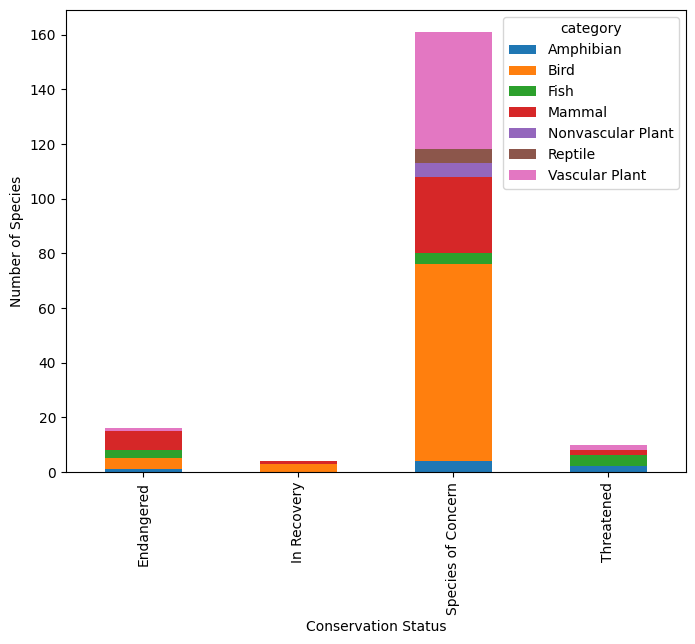

In [17]:
ax = conservationCategory.plot(kind = 'bar', figsize=(8,6), 
                               stacked=True)
ax.set_xlabel("Conservation Status")
ax.set_ylabel("Number of Species");

#### In Conservation

Another question that we want to investigate is "Are certain types of species more likely to be endangered?" We can answer this question by creating a new column called `projected` and including all species that have a value other than `No Intervention`.

In [18]:
species['projected'] = species.conservation_status != "No Intervention"

Next, we group by `category` and `projected` and then inspect the results of our question.

Through this inspection, we can see that Birds, Vascular Plants, and Mammals have a higher number of species protected.

In [19]:
category_counts = species.groupby(['category', 'projected'])\
                        .scientific_name.nunique()\
                        .reset_index()\
                        .pivot(columns='projected', 
                               index='category', 
                               values='scientific_name')\
                        .reset_index()
category_counts.columns = ['category', 'not_protected', 'protected']

category_counts

,category,not_protected,protected
0,Amphibian,72,7
1,Bird,413,75
2,Fish,115,11
3,Mammal,146,30
4,Nonvascular Plant,328,5
5,Reptile,73,5
6,Vascular Plant,4216,46


While the absolute numbers in the chart are a good start, we should also make sure that we calculate the rate of protection for each category in the data. When we do this, we can see that ~17 percent of mammals are under protection, as well as ~15 percent of birds.

In [20]:
category_counts['pct_protected'] = category_counts.protected / \
                                (category_counts.protected + category_counts.not_protected) * 100

category_counts


,category,not_protected,protected,pct_protected
0,Amphibian,72,7,8.860759
1,Bird,413,75,15.368852
2,Fish,115,11,8.730159
3,Mammal,146,30,17.045455
4,Nonvascular Plant,328,5,1.501502
5,Reptile,73,5,6.410256
6,Vascular Plant,4216,46,1.079305


#### Statistical Significance

In this section, we will run chi-squared tests in order to see if differnet species have statistically significant differences in their conservation status rates. 

Note: A "chi-squared" test is a statistical tool used to determine if two categorical variables are indepoendent or unrelated. It does this through comparing observed values to expected values to determine if the differnece in those values is statistically significant

First, we will need to create a contingency table that will look as followed:

||protected|not protected|
|-|-|-|
|Mammal|?|?|
|Bird|?|?|

Our first contingency table will be called `mb_contingency`, and we will use it to see if there is a significant relationship between mammals and birds.

When our results are returned, we notice that the chi-squared tests returns two values and an array. The second value that is returned is the p-value, which is 0.69 in this case. Standard p-values that we may attribute to significance would be 0.1, 0.05, and 0.01. Here, we can see that this p-value is much larger than all of those standard values, meaning that there does not seem to be any significant relationship between mammals and birds.

In [23]:
from scipy.stats import chi2_contingency

mb_contingency = [[30, 146],
                  [75, 413]]
chi2_contingency(mb_contingency)

Chi2ContingencyResult(statistic=np.float64(0.1617014831654557), pvalue=np.float64(0.6875948096661336), dof=1, expected_freq=array([[ 27.8313253, 148.1686747],
       [ 77.1686747, 410.8313253]]))

Next, we will create another contingency table in order to perform another chi-squared test between `Reptile` and `Mammal`.

||protected|not protected|
|-|-|-|
|Mammal|?|?|
|Reptile|?|?|

When our results are returned this time, we can see that the p-value is 0.039. With this result under a 0.1 and a 0.05 significance threshold, we can say that there is a statistically significant difference between reptiles and mammals when it comes to needing protection. In this case, Mammals are proven to have statistically significant higher rates of needed protection when being compared to reptiles.

In [24]:
mr_contingency = [[30, 146], 
                  [5, 73]]
chi2_contingency(mr_contingency)

Chi2ContingencyResult(statistic=np.float64(4.289183096203645), pvalue=np.float64(0.03835559022969898), dof=1, expected_freq=array([[ 24.2519685, 151.7480315],
       [ 10.7480315,  67.2519685]]))

#### Species in Parks